# import 

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

# 데이터 로드

In [2]:
# 0) 데이터 로드
df = pd.read_csv("diabetes_prediction_dataset.csv", encoding="cp949")
df.info() # 데이터 타입 확인 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   성별        100000 non-null  object 
 1   나이        100000 non-null  float64
 2   고혈압 여부    100000 non-null  int64  
 3   심장질환 여부   100000 non-null  int64  
 4   흡연 경험     100000 non-null  object 
 5   BMI 지수    100000 non-null  float64
 6   당화혈색소 수치  100000 non-null  float64
 7   혈당 수치     100000 non-null  int64  
 8   당뇨병 여부    100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


# 데이터 분할 

Train:Valid:Test=7:2:1

In [3]:
print("\n" + "="*60)
print("데이터 분할: Train(70%) : Valid(20%) : Test(10%)")
print("="*60)

target_col = "당뇨병 여부"

# 1단계: Train+Valid(90%) vs Test(10%)
train_val_df, test_df = train_test_split(
    df, 
    test_size=0.1,  
    random_state=42, 
    stratify=df[target_col]
)

# 2단계: Train(70%) vs Valid(20%)
train_df, valid_df = train_test_split(
    train_val_df,
    test_size=0.2222,  
    random_state=42,
    stratify=train_val_df[target_col]
)

print(f"\nTrain: {len(train_df):,}개 ({len(train_df)/len(df)*100:.1f}%)")
print(f"Valid: {len(valid_df):,}개 ({len(valid_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df):,}개 ({len(test_df)/len(df)*100:.1f}%)")

# 타겟 분포 확인
print(f"\n타겟 변수 분포:")
print(f"Train - 0: {(train_df[target_col]==0).sum()/len(train_df)*100:.2f}%, 1: {(train_df[target_col]==1).sum()/len(train_df)*100:.2f}%")
print(f"Valid - 0: {(valid_df[target_col]==0).sum()/len(valid_df)*100:.2f}%, 1: {(valid_df[target_col]==1).sum()/len(valid_df)*100:.2f}%")
print(f"Test  - 0: {(test_df[target_col]==0).sum()/len(test_df)*100:.2f}%, 1: {(test_df[target_col]==1).sum()/len(test_df)*100:.2f}%")

# X, y 분리
X_train_raw = train_df.drop(target_col, axis=1).copy()
y_train = train_df[target_col].copy()

X_valid_raw = valid_df.drop(target_col, axis=1).copy()
y_valid = valid_df[target_col].copy()

X_test_raw = test_df.drop(target_col, axis=1).copy()
y_test = test_df[target_col].copy()

# 1. 데이터 크기(행, 열) 확인: 데이터가 의도대로 잘 쪼개졌는지 체크
print(f"\n학습용 데이터 크기: {X_train_raw.shape}, 정답: {y_train.shape}")
print(f"검증용 데이터 크기: {X_valid_raw.shape}, 정답: {y_valid.shape}")
print(f"테스트용 데이터 크기: {X_test_raw.shape}, 정답: {y_test.shape}")

# 2. 타깃(종속변수) 비율 확인: stratify가 잘 작동해서 비율이 깨지지 않았는지 체크
print(f"\n학습 데이터 타깃 비율:\n{y_train.value_counts(normalize=True)}")


데이터 분할: Train(70%) : Valid(20%) : Test(10%)

Train: 70,002개 (70.0%)
Valid: 19,998개 (20.0%)
Test:  10,000개 (10.0%)

타겟 변수 분포:
Train - 0: 91.50%, 1: 8.50%
Valid - 0: 91.50%, 1: 8.50%
Test  - 0: 91.50%, 1: 8.50%

학습용 데이터 크기: (70002, 8), 정답: (70002,)
검증용 데이터 크기: (19998, 8), 정답: (19998,)
테스트용 데이터 크기: (10000, 8), 정답: (10000,)

학습 데이터 타깃 비율:
당뇨병 여부
0    0.915002
1    0.084998
Name: proportion, dtype: float64


# 데이터 전처리 

## 1. 결측치 처리

결측치가 없어서 안해도 됨

In [4]:
print("\n" + "="*60)
print("결측치 확인")
print("="*60)
print(df.isnull().sum())


결측치 확인
성별          0
나이          0
고혈압 여부      0
심장질환 여부     0
흡연 경험       0
BMI 지수      0
당화혈색소 수치    0
혈당 수치       0
당뇨병 여부      0
dtype: int64


## 2. 이상치 처리

- [나이], [흡연 경험] -> 범주형 변수(추후 다룸)
- [고혈압 여부], [심장질환 여부] -> 이진값이므로 제외 
- [나이] -> 최솟값 0.08, 최댓값 80으로 정상 범위이므로 제외 
- [당화혈색소 수치], [혈당 수치] -> "이상치 내부 당뇨 환자 분포"가 100% 이므로 이상치가 아닌 유의미한 데이터. 

-> 따라서 [BMI 지수]에 대해서만 이상치 처리 진행. 

In [5]:
df.describe()

,나이,고혈압 여부,심장질환 여부,BMI 지수,당화혈색소 수치,혈당 수치,당뇨병 여부
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
# 분석할 컬럼 목록
target_cols = ['BMI 지수', '당화혈색소 수치', '혈당 수치']

def analyze_outliers_detailed(df, col):
    """
    특정 컬럼에 대해 IQR 기반 이상치를 분석하고 리포트를 출력하는 함수
    """
    # 1) IQR 및 정상 범위 계산
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"■ [{col}]")
    print(f"1) 정상 범위: {lower_bound:.2f} ~ {upper_bound:.2f}")
    
    # 2) 이상치 데이터 발색 (필터링)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    total_count = len(df)
    outlier_count = len(outliers)
    
    print(f"2) 이상치 개수: {outlier_count}개")
    
    # 3) 이상치 중 당뇨(Positive) 비율 분석
    if outlier_count > 0:
        diabetes_in_outliers = outliers[outliers['당뇨병 여부'] == 1]
        diabetes_count = len(diabetes_in_outliers)
        diabetes_ratio = (diabetes_count / outlier_count) * 100
        
        print(f"3) 이상치 내부 당뇨 환자 분포:")
        print(f"   - 당뇨 환자 수: {diabetes_count}명")
        print(f"   - 당뇨 비율: {diabetes_ratio:.2f}%")
        
        # 비교를 위해 전체 데이터의 당뇨 비율도 함께 출력하면 좋습니다
        total_diabetes_ratio = (df['당뇨병 여부'].sum() / total_count) * 100
    else:
        print("3) 발견된 이상치가 없습니다.")
        
    print("=" * 50)  # 구분선

# 실행
for col in target_cols:
    analyze_outliers_detailed(df, col)

■ [BMI 지수]
1) 정상 범위: 14.71 ~ 38.50
2) 이상치 개수: 7086개
3) 이상치 내부 당뇨 환자 분포:
   - 당뇨 환자 수: 1478명
   - 당뇨 비율: 20.86%
■ [당화혈색소 수치]
1) 정상 범위: 2.70 ~ 8.30
2) 이상치 개수: 1315개
3) 이상치 내부 당뇨 환자 분포:
   - 당뇨 환자 수: 1315명
   - 당뇨 비율: 100.00%
■ [혈당 수치]
1) 정상 범위: 11.50 ~ 247.50
2) 이상치 개수: 2038개
3) 이상치 내부 당뇨 환자 분포:
   - 당뇨 환자 수: 2038명
   - 당뇨 비율: 100.00%


- [BMI 지수]가 높을수록 당뇨 여부에 영향이 있을 것으로 판단
- 따라서 정상 범위 최댓값보다 큰 이상치들을 상한값으로 대체
- 정상 범위 최솟값보다 작은 이상치들은 당뇨 여부에 큰 영향이 없을 것으로 판단하고 별도의 처리 X

In [7]:
bmi_col = "BMI 지수"

Q1 = X_train_raw[bmi_col].quantile(0.25)
Q3 = X_train_raw[bmi_col].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print(f"✅ BMI 상한값(Upper Limit): {upper_limit:.2f}")

# 2. 학습 데이터(X_train_raw)에 적용: 상한값보다 큰 값은 상한값으로 대체 (Clipping)
X_train_raw[bmi_col] = X_train_raw[bmi_col].clip(upper=upper_limit)

# 3. 검증/테스트 데이터에도 '학습 데이터에서 구한 기준' 그대로 적용
X_valid_raw[bmi_col] = X_valid_raw[bmi_col].clip(upper=upper_limit)
X_test_raw[bmi_col] = X_test_raw[bmi_col].clip(upper=upper_limit)

print(">> 이상치 처리 완료: 상한값 초과 데이터를 상한값으로 대체했습니다.")

# (선택) 처리 후 최댓값이 상한값과 같아졌는지 확인
print(f"처리 후 Train BMI 최대값: {X_train_raw[bmi_col].max()}")
print(f"처리 후 Valid BMI 최대값: {X_valid_raw[bmi_col].max()}")
print(f"처리 후 Test BMI 최대값: {X_test_raw[bmi_col].max()}")

✅ BMI 상한값(Upper Limit): 38.43
>> 이상치 처리 완료: 상한값 초과 데이터를 상한값으로 대체했습니다.
처리 후 Train BMI 최대값: 38.43000000000001
처리 후 Valid BMI 최대값: 38.43000000000001
처리 후 Test BMI 최대값: 38.43000000000001


## 3. 범주형 변수 인코딩

- [성별]: Male/Female 이외의 값은 불가능하고, 총 10만 개의 데이터 중 15개뿐인 'Others' 카테고리를 제거한 후 Male과 Female을 레이블 인코딩

- [흡연 경험]: 카테고리 총 6개 -> 원-핫 인코딩 

In [8]:
cat_cols = ["성별", "흡연 경험"]

for col in cat_cols:
    print(f"■ [{col}] 카테고리 분포")
    # dropna=False를 넣으면 결측치(NaN)가 있는지도 함께 보여줍니다
    print(X_train_raw[col].value_counts(dropna=False))
    print("-" * 30)


■ [성별] 카테고리 분포
성별
Female    40949
Male      29038
Other        15
Name: count, dtype: int64
------------------------------
■ [흡연 경험] 카테고리 분포
흡연 경험
No Info        24985
never          24579
former          6572
current         6477
not current     4588
ever            2801
Name: count, dtype: int64
------------------------------


In [9]:
print(f"삭제 전 크기: {X_train_raw.shape}")

# 성별이 'Other'가 아닌 것만 남기기
X_train_raw = X_train_raw[X_train_raw['성별'] != 'Other'].copy()
X_valid_raw = X_valid_raw[X_valid_raw['성별'] != 'Other'].copy()
X_test_raw = X_test_raw[X_test_raw['성별'] != 'Other'].copy()

# 삭제 후 y(정답지) 데이터도 인덱스 맞춰서 줄여줘야 함 (매우 중요!)
y_train = y_train[X_train_raw.index]
y_valid = y_valid[X_valid_raw.index]
y_test = y_test[X_test_raw.index]

print(f"삭제 후 크기: {X_train_raw.shape}")

# 2. 성별을 0과 1로 매핑 (이제 카테고리가 2개뿐이므로 순서 문제 없음)
gender_map = {'Female': 0, 'Male': 1}

X_train_raw['성별'] = X_train_raw['성별'].map(gender_map)
X_valid_raw['성별'] = X_valid_raw['성별'].map(gender_map)
X_test_raw['성별'] = X_test_raw['성별'].map(gender_map)

# 3. 데이터 타입 확인 (정수형으로 잘 바뀌었는지)
print("\n[변환 후 성별 분포]")
print(X_train_raw['성별'].value_counts())

삭제 전 크기: (70002, 8)
삭제 후 크기: (69987, 8)

[변환 후 성별 분포]
성별
0    40949
1    29038
Name: count, dtype: int64


In [10]:
target_cat_col = ["흡연 경험"]

# 1. 인코더 생성
# handle_unknown='ignore': 학습 때 없던 새로운 흡연 상태가 테스트 때 나오면 에러 없이 0으로 처리
# sparse_output=False: 결과를 바로 보기 편한 배열(Array) 형태로 받음
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 2. 학습 데이터(X_train_raw)로 학습 및 변환
train_smoking_encoded = encoder.fit_transform(X_train_raw[target_cat_col])

# 3. 검증/테스트 데이터 변환 (Transform Only)
valid_smoking_encoded = encoder.transform(X_valid_raw[target_cat_col])
test_smoking_encoded = encoder.transform(X_test_raw[target_cat_col])

# 4. 인코딩된 결과를 DataFrame으로 예쁘게 만들기
new_cols = encoder.get_feature_names_out(target_cat_col)

train_smoking_df = pd.DataFrame(train_smoking_encoded, columns=new_cols, index=X_train_raw.index)
valid_smoking_df = pd.DataFrame(valid_smoking_encoded, columns=new_cols, index=X_valid_raw.index)
test_smoking_df = pd.DataFrame(test_smoking_encoded, columns=new_cols, index=X_test_raw.index)

# 5. 기존 데이터와 합치기 (Concat)
X_train_final = pd.concat([X_train_raw.drop(columns=target_cat_col), train_smoking_df], axis=1)
X_valid_final = pd.concat([X_valid_raw.drop(columns=target_cat_col), valid_smoking_df], axis=1)
X_test_final = pd.concat([X_test_raw.drop(columns=target_cat_col), test_smoking_df], axis=1)

print("✅ '흡연 경험' 원-핫 인코딩 완료!")
print(f"\n생성된 컬럼 목록: {new_cols}")

# 결과 확인
print("\n[최종 데이터 샘플]")
print(X_train_final.head())

✅ '흡연 경험' 원-핫 인코딩 완료!

생성된 컬럼 목록: ['흡연 경험_No Info' '흡연 경험_current' '흡연 경험_ever' '흡연 경험_former' '흡연 경험_never'
 '흡연 경험_not current']

[최종 데이터 샘플]
       성별    나이  고혈압 여부  심장질환 여부  BMI 지수  당화혈색소 수치  혈당 수치  흡연 경험_No Info  \
13054   1  32.0       0        0   23.80       4.0    140            0.0   
15840   0  38.0       0        0   30.13       3.5    145            0.0   
80508   0  38.0       0        0   27.32       4.0    145            1.0   
64238   0   4.0       0        0   18.08       6.1    155            1.0   
70834   0  72.0       0        0   22.36       6.1    130            0.0   

       흡연 경험_current  흡연 경험_ever  흡연 경험_former  흡연 경험_never  흡연 경험_not current  
13054            0.0         0.0           0.0          1.0                0.0  
15840            0.0         0.0           0.0          1.0                0.0  
80508            0.0         0.0           0.0          0.0                0.0  
64238            0.0         0.0           0.0          0.0                

# 모델 학습 및 예측

- Recall vs Precision: 정상을 당뇨라고 착각(FP)했다면 다시 검사하면 되지만, 당뇨인데 정상으로 오진(FN)했다면 매우 심각한 문제. 가장 중요한 목적은 "양성 클래스(당뇨)를 찾아내는 것", 즉 Recall이 더 중요(실제 정답(Positive)인 것을 놓치지 않고 찾아내는 것)

- f1-score: Class 1 (Positive)의 f1-score에 주목. 현재 데이터셋은 정상 데이터가 훨씬 많기 때문에 음성 클래스(정상)는 대충 때려맞춰도 맞았을 확률이 높음. 즉 음성 클래스(정상)와 관련된 "0 기준 f1-score"와 "macro f1-score"는 객관적인 지표값이 아니다.  

- macro Avg: 데이터의 개수와 상관없이 **Class 0(정상)**과 **Class 1(당뇨)**의 점수를 단순히 더해서 반으로 나눔. 즉 뻥튀기 된 "0 기준 f1-score"의 영향이 있기 때문에 적절하지 않다. 

✅ 모델 학습 완료

     📊 Validation Set 성능 평가     

[핵심 지표 - Validation]
👉 Accuracy (정확도):  0.9700
👉 Precision (정밀도): 0.9393
👉 Recall (재현율):    0.6924
👉 F1-Score:          0.7972
👉 ROC AUC Score:     0.9639


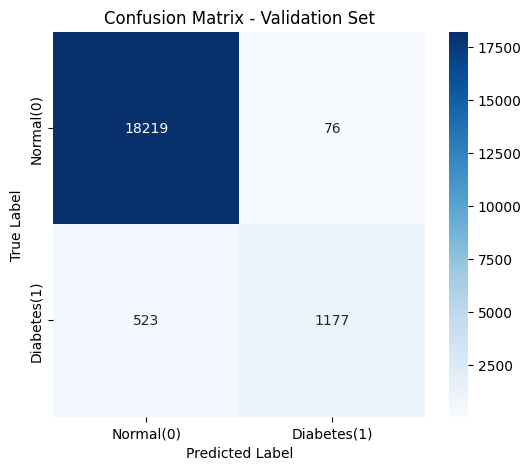

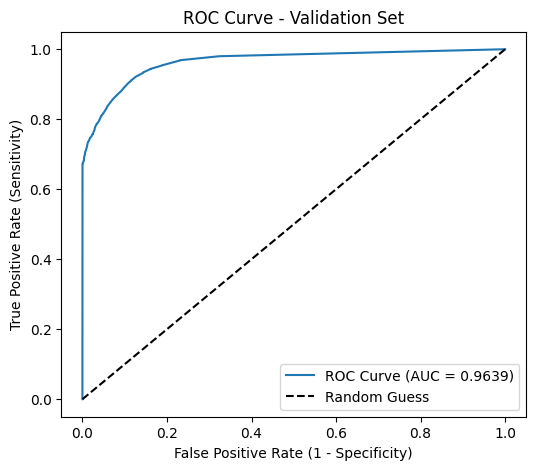


[Confusion Matrix 요약 - Validation]
TN (정상을 정상으로): 18219명
FP (정상을 당뇨로):   76명
FN (당뇨를 놓침):     523명 -> 🚨 집중 관리 대상
TP (당뇨를 당뇨로):   1177명

     📊 Test Set 성능 평가 (최종)     

[핵심 지표 - Test]
👉 Accuracy (정확도):  0.9699
👉 Precision (정밀도): 0.9392
👉 Recall (재현율):    0.6906
👉 F1-Score:          0.7959
👉 ROC AUC Score:     0.9605


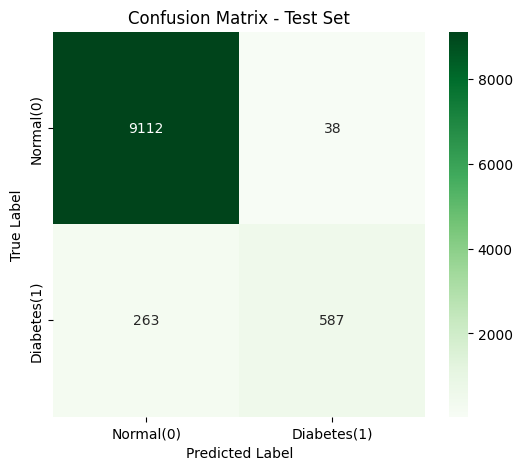

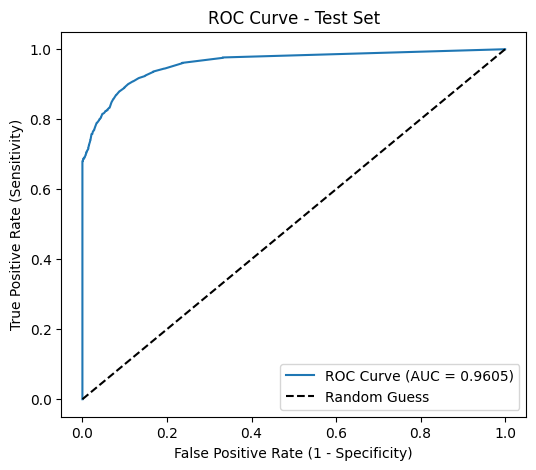


[Confusion Matrix 요약 - Test]
TN (정상을 정상으로): 9112명
FP (정상을 당뇨로):   38명
FN (당뇨를 놓침):     263명 -> 🚨 집중 관리 대상
TP (당뇨를 당뇨로):   587명

        🔬 임계값 조정 실험 (Validation)        

[일반 범위 임계값 테스트]
 Threshold  Accuracy  Precision   Recall       F1
       0.1  0.914179   0.497308 0.869412 0.632705
       0.2  0.947137   0.656296 0.794118 0.718659
       0.3  0.960490   0.778117 0.748824 0.763189
       0.4  0.967892   0.886696 0.713529 0.790743
       0.5  0.970043   0.939346 0.692353 0.797155
       0.6  0.970843   0.969722 0.678235 0.798200
       0.7  0.971693   0.990484 0.673529 0.801821
       0.8  0.971993   1.000000 0.670588 0.802817
       0.9  0.971893   1.000000 0.669412 0.801973

     🚨 극단 상황 시뮬레이션     

[극단 임계값 테스트]
 Threshold  Accuracy  Precision   Recall       F1
     0.001  0.701825   0.219384 0.980000 0.358511
     0.999  0.938635   1.000000 0.278235 0.435343

💡 해석:
  - Threshold=0.001: 거의 모든 데이터를 '당뇨(1)'로 예측 → Recall은 매우 높지만 Precision 폭락
  - Threshold=0.999: 극소수만 '당뇨(1)'로 예측 → Pre

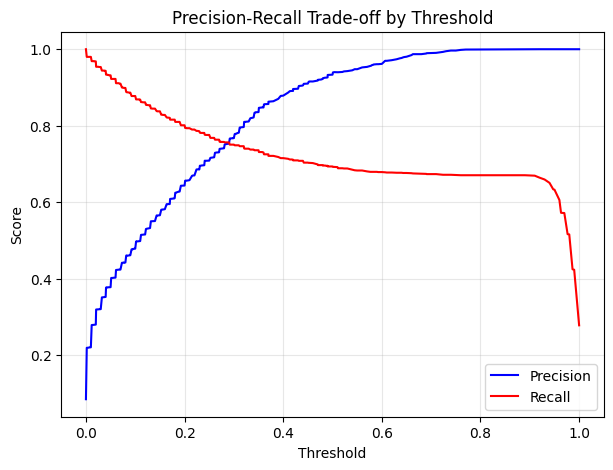

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 모델 생성
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. 모델 학습 (Train 데이터)
rf_model.fit(X_train_final, y_train)
print("✅ 모델 학습 완료")

# 3. 예측 수행 (Valid 세트로 평가)
print("\n" + "="*40)
print("     📊 Validation Set 성능 평가     ")
print("="*40)

# (1) 클래스 예측 (0, 1)
y_valid_pred = rf_model.predict(X_valid_final)
# (2) 확률 예측 (ROC AUC 계산용, 1일 확률)
y_valid_pred_proba = rf_model.predict_proba(X_valid_final)[:, 1]

# 4. 성능 평가
# (1) 4대 지표 측정 (정확도 추가)
valid_acc = accuracy_score(y_valid, y_valid_pred)
valid_prec = precision_score(y_valid, y_valid_pred)
valid_rec = recall_score(y_valid, y_valid_pred)
valid_f1 = f1_score(y_valid, y_valid_pred)

print("\n[핵심 지표 - Validation]")
print(f"👉 Accuracy (정확도):  {valid_acc:.4f}")
print(f"👉 Precision (정밀도): {valid_prec:.4f}")
print(f"👉 Recall (재현율):    {valid_rec:.4f}")
print(f"👉 F1-Score:          {valid_f1:.4f}")

# (2) ROC AUC Score 확인
valid_roc_auc = roc_auc_score(y_valid, y_valid_pred_proba)
print(f"👉 ROC AUC Score:     {valid_roc_auc:.4f}")

# (3) Confusion Matrix 시각화
cm_valid = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_valid, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal(0)', 'Diabetes(1)'], 
            yticklabels=['Normal(0)', 'Diabetes(1)'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# (4) ROC Curve 시각화
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, y_valid_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_valid, tpr_valid, label=f'ROC Curve (AUC = {valid_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Validation Set')
plt.legend()
plt.show()

# 텍스트 요약
print("\n[Confusion Matrix 요약 - Validation]")
print(f"TN (정상을 정상으로): {cm_valid[0][0]}명")
print(f"FP (정상을 당뇨로):   {cm_valid[0][1]}명")
print(f"FN (당뇨를 놓침):     {cm_valid[1][0]}명 -> 🚨 집중 관리 대상")
print(f"TP (당뇨를 당뇨로):   {cm_valid[1][1]}명")

# ---------------------------------------------------------
# Test Set 평가
# ---------------------------------------------------------
print("\n" + "="*40)
print("     📊 Test Set 성능 평가 (최종)     ")
print("="*40)

y_test_pred = rf_model.predict(X_test_final)
y_test_pred_proba = rf_model.predict_proba(X_test_final)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("\n[핵심 지표 - Test]")
print(f"👉 Accuracy (정확도):  {test_acc:.4f}")
print(f"👉 Precision (정밀도): {test_prec:.4f}")
print(f"👉 Recall (재현율):    {test_rec:.4f}")
print(f"👉 F1-Score:          {test_f1:.4f}")
print(f"👉 ROC AUC Score:     {test_roc_auc:.4f}")

cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal(0)', 'Diabetes(1)'], 
            yticklabels=['Normal(0)', 'Diabetes(1)'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_test, tpr_test, label=f'ROC Curve (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Test Set')
plt.legend()
plt.show()

print("\n[Confusion Matrix 요약 - Test]")
print(f"TN (정상을 정상으로): {cm_test[0][0]}명")
print(f"FP (정상을 당뇨로):   {cm_test[0][1]}명")
print(f"FN (당뇨를 놓침):     {cm_test[1][0]}명 -> 🚨 집중 관리 대상")
print(f"TP (당뇨를 당뇨로):   {cm_test[1][1]}명")


# ---------------------------------------------------------
# [추가 실험] 임계값(Threshold) 조정 실험
# ---------------------------------------------------------

from sklearn.preprocessing import Binarizer

# 1. 특정 임계값 적용 함수 정의
def get_clf_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    """
    다양한 임계값에서 평가 지표를 계산하는 함수

    Parameters:
    - y_test: 실제 정답 (0 or 1)
    - pred_proba_c1: 클래스 1일 확률 (0.0 ~ 1.0)
    - thresholds: 테스트할 임계값 리스트 (예: [0.3, 0.5, 0.7])

    Returns:
    - DataFrame: 임계값별 Accuracy, Precision, Recall, F1-Score
    """
    eval_list = []

    for custom_threshold in thresholds:
        # 임계값 적용: threshold보다 크면 1, 작으면 0
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1.reshape(-1, 1))
        custom_predict = binarizer.transform(pred_proba_c1.reshape(-1, 1))

        # 지표 계산
        acc = accuracy_score(y_test, custom_predict)
        prec = precision_score(y_test, custom_predict, zero_division=0)
        rec = recall_score(y_test, custom_predict, zero_division=0)
        f1 = f1_score(y_test, custom_predict, zero_division=0)

        eval_list.append([custom_threshold, acc, prec, rec, f1])

    return pd.DataFrame(eval_list, columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1'])


# ---------------------------------------------------------
# [실험 1] 다양한 임계값에서의 지표 변화 확인 (Validation Set)
# ---------------------------------------------------------
print("\n" + "="*50)
print("        🔬 임계값 조정 실험 (Validation)        ")
print("="*50)

# 0.1부터 0.9까지 0.1 단위로 테스트
thresholds_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
df_eval = get_clf_eval_by_threshold(y_valid, y_valid_pred_proba, thresholds_test)

print("\n[일반 범위 임계값 테스트]")
print(df_eval.to_string(index=False))


# ---------------------------------------------------------
# [실험 2] 극단적 임계값: Recall 100% vs Precision 100%
# ---------------------------------------------------------
print("\n" + "="*50)
print("     🚨 극단 상황 시뮬레이션     ")
print("="*50)

# Recall 100% 만들기: 임계값을 거의 0에 가깝게 (모든 데이터를 1로 예측)
# Precision 100% 만들기: 임계값을 거의 1에 가깝게 (확실한 것만 1로 예측)
extreme_thresholds = [0.001, 0.999]
df_extreme = get_clf_eval_by_threshold(y_valid, y_valid_pred_proba, extreme_thresholds)

print("\n[극단 임계값 테스트]")
print(df_extreme.to_string(index=False))

print("\n💡 해석:")
print("  - Threshold=0.001: 거의 모든 데이터를 '당뇨(1)'로 예측 → Recall은 매우 높지만 Precision 폭락")
print("  - Threshold=0.999: 극소수만 '당뇨(1)'로 예측 → Precision은 높지만 Recall 폭락")


# ---------------------------------------------------------
# [보너스] Precision-Recall Curve 시각화 (Trade-off 확인)
# ---------------------------------------------------------
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_curve = precision_recall_curve(y_valid, y_valid_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(thresholds_curve, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds_curve, recalls[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off by Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 교차 검증 

왜 성능이 안올랐을까?

- 모델의 성능을 높여주는 '튜닝 도구'가 아니라, 모델의 진짜 실력을 측정하는 '검진 도구'이다. 

- 점수가 뚝 떨어지지 않고 거의 비슷하게 유지되었다는 것은, 모델이 특정 데이터셋(Train Set)에만 잘 동작하는 '운 좋은 모델(과적합)'이 아니라, 어떤 데이터가 와도 일관된 성능을 내는 '튼튼한 모델(Robustness)'임을 증명

- 단일 분할(Train/Test)에서 나온 0.7949라는 점수가 "운 좋게 쉬운 문제만 풀어서 나온 가짜 점수"인지 확인하기 위해서였습니다. 확인 결과, 가짜가 아니었음이 증명된 것

In [12]:
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold

# ---------------------------------------------------------
# [5] 교차 검증 (Cross Validation) 비교
# ---------------------------------------------------------

# 평가할 지표들 (F1, Precision, Recall, Accuracy)
scoring = ['f1', 'precision', 'recall', 'accuracy']

# 1. KFold (단순 등분할) 설정
# n_splits=5: 데이터를 5등분
# shuffle=True: 섞어서 나눔 (데이터가 순서대로 정렬되어 있을 수 있으므로 필수)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. StratifiedKFold (비율 유지 분할) 설정
# 정답(y)의 비율(0과 1)을 유지하면서 나눔 -> 불균형 데이터에 유리
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------
# 실행 및 결과 비교 함수
# ---------------------------------------------------------
def run_cv(model, X, y, cv, name):
    print(f"🔄 [{name}] 교차 검증 시작...", end="")

    # cross_validate: 여러 지표를 한 번에 계산해줌
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    print(" 완료!")
    print(f"   - 평균 F1-Score: {np.mean(scores['test_f1']):.4f} (±{np.std(scores['test_f1']):.4f})")
    print(f"   - 평균 Recall:   {np.mean(scores['test_recall']):.4f}")
    print(f"   - 평균 Precision:{np.mean(scores['test_precision']):.4f}")
    print(f"   - 평균 Accuracy: {np.mean(scores['test_accuracy']):.4f}")  
    return scores

print("\n" + "="*50)
print("             📊 교차 검증 성능 비교             ")
print("="*50)

# (1) KFold 실행
# 주의: KFold는 y의 비율을 고려하지 않고 무작위로 자름
scores_kfold = run_cv(rf_model, X_train_final, y_train, kfold, "Standard KFold")

print("-" * 50)

# (2) StratifiedKFold 실행
# 주의: StratifiedKFold는 각 폴드마다 당뇨 환자 비율을 원본과 똑같이 맞춤
scores_stratified = run_cv(rf_model, X_train_final, y_train, stratified_kfold, "Stratified KFold")

print("="*50)


             📊 교차 검증 성능 비교             
🔄 [Standard KFold] 교차 검증 시작... 완료!
   - 평균 F1-Score: 0.7899 (±0.0130)
   - 평균 Recall:   0.6804
   - 평균 Precision:0.9417
   - 평균 Accuracy: 0.9693
--------------------------------------------------
🔄 [Stratified KFold] 교차 검증 시작... 완료!
   - 평균 F1-Score: 0.7887 (±0.0053)
   - 평균 Recall:   0.6805
   - 평균 Precision:0.9380
   - 평균 Accuracy: 0.9690


- n_estimators: 많을수록 집단지성의 힘으로 똑똑해지지만, 100그루가 넘어가면 성능 향상은 미미한데 속도만 느려집니다. 

- max_depth: 너무 깊으면(숫자가 크면) 너무 집요하게 파고들어서 과적합이 됩니다. 적당히 제한해야 함.

- min_samples_split: 너무 자잘한 분할 방지

- min_samples_leaf: 소수 데이터 무시

In [13]:
# 1. 파라미터 그리드 축소 (노트북 환경 최적화)
param_grid = {
    # 100, 200 두 개만 봅니다. (300은 너무 오래 걸림)
    'n_estimators': [100, 200],

    # 깊이는 10, 20 두 개만 봅니다.
    'max_depth': [10, 20],

    # 가지치기 옵션은 하나씩만 넣거나 범위를 좁힙니다.
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 4]
}

# 총 조합 수: 2 x 2 x 3 x 2 = 24개
# 총 학습 횟수: 24개 x 5-Fold = 120번 (900번 -> 120번으로 1/7 감축)

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,

    # [핵심] verbose를 2나 3으로 설정하면 진행 상황이 실시간으로 뜹니다!
    verbose=2  
)

print(f"⏳ 튜닝 시작 (총 {24}개 조합 x 5-Fold = {120}번 학습)")

grid_search.fit(X_train_final, y_train)

# (이후 결과 출력 코드는 동일)
print("\n✅ 튜닝 완료!")
print(f"👉 최적의 파라미터: {grid_search.best_params_}")
print(f"👉 최고 F1-Score: {grid_search.best_score_:.4f}")


# 최적 모델로 최종 성능 확인 (선택 사항)
best_model = grid_search.best_estimator_

# Validation으로 확인
y_valid_pred_best = best_model.predict(X_valid_final)
print("\n[최적 모델 성능 리포트 - Validation]")
print(classification_report(y_valid, y_valid_pred_best, digits=4))

# Test로 최종 확인
y_test_pred_best = best_model.predict(X_test_final)
print("\n[최적 모델 성능 리포트 - Test]")
print(classification_report(y_test, y_test_pred_best, digits=4))

⏳ 튜닝 시작 (총 24개 조합 x 5-Fold = 120번 학습)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ 튜닝 완료!
👉 최적의 파라미터: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
👉 최고 F1-Score: 0.8009

[최적 모델 성능 리포트 - Validation]
              precision    recall  f1-score   support

           0     0.9712    0.9991    0.9849     18295
           1     0.9864    0.6806    0.8054      1700

    accuracy                         0.9720     19995
   macro avg     0.9788    0.8399    0.8952     19995
weighted avg     0.9724    0.9720    0.9697     19995


[최적 모델 성능 리포트 - Test]
              precision    recall  f1-score   support

           0     0.9715    0.9995    0.9853      9150
           1     0.9915    0.6847    0.8100       850

    accuracy                         0.9727     10000
   macro avg     0.9815    0.8421    0.8977     10000
weighted avg     0.9732    0.9727    0.9704     10000

